In [2]:
# 1) Load CSV into pandas and show first rows
import pandas as pd
import matplotlib.pyplot as plt
path = r"c:\Users\alek3\Documents\Uni\Scientific Computing Master\5. Semester SciComp Barcelona\Presentation_Visualization\accidents_bcn_2019_2025.csv"
df = pd.read_csv(path, encoding='utf-8', low_memory=False)
df.head()

,numero_expedient,codi_districte,nom_districte,nom_barri,nom_carrer,nk_any,mes_any,nom_mes,dia_mes,hora_dia,...,latitud,fichero_origen,es_causa_vianant,fecha,dia_semana,fin_de_semana,franja_horaria,total_lesionados,gravedad,accidente_con_victimas
0,2019S000001,5.0,Sarrià-Sant Gervasi,Sant Gervasi - Galvany,Diagonal / Augusta,2019,1,Gener,1,1,...,41.395744,2019_accidents_gu_bcn.csv,False,2019-01-01,Tuesday,Laborable,Madrugada (00-06h),1,Grave,True
1,2019S000002,9.0,Sant Andreu,el Congrés i els Indians,Felip II / Congrés Eucarístic,2019,1,Gener,1,4,...,41.425361,2019_accidents_gu_bcn.csv,False,2019-01-01,Tuesday,Laborable,Madrugada (00-06h),1,Leve,True
2,2019S000003,10.0,Sant Martí,el Parc i la Llacuna del Poblenou,Pallars,2019,1,Gener,1,5,...,41.396887,2019_accidents_gu_bcn.csv,True,2019-01-01,Tuesday,Laborable,Madrugada (00-06h),1,Leve,True
3,2019S000004,6.0,Gràcia,el Camp d'en Grassot i Gràcia Nova,Taxdirt / Nogués,2019,1,Gener,1,8,...,41.408772,2019_accidents_gu_bcn.csv,False,2019-01-01,Tuesday,Laborable,Manana (06-12h),1,Leve,True
4,2019S000005,2.0,Eixample,la Dreta de l'Eixample,Consell de Cent / Girona,2019,1,Gener,1,12,...,41.394884,2019_accidents_gu_bcn.csv,False,2019-01-01,Tuesday,Laborable,Tarde (12-18h),2,Leve,True


In [13]:
# 2) Quick overview: info, shape
print(df.shape)
df.info()

(54954, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54954 entries, 0 to 54953
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   numero_expedient           54954 non-null  object 
 1   codi_districte             54722 non-null  float64
 2   nom_districte              54722 non-null  object 
 3   nom_barri                  54722 non-null  object 
 4   nom_carrer                 54953 non-null  object 
 5   nk_any                     54954 non-null  int64  
 6   mes_any                    54954 non-null  int64  
 7   nom_mes                    54954 non-null  object 
 8   dia_mes                    54954 non-null  int64  
 9   hora_dia                   54954 non-null  int64  
 10  descripcio_dia_setmana     54954 non-null  object 
 11  descripcio_torn            54954 non-null  object 
 12  descripcio_causa_vianant   54954 non-null  object 
 13  numero_morts               54954 n

In [14]:
# 3) Missing values and summary
missing = df.isna().sum().sort_values(ascending=False)
missing[missing>0]

# full descriptive table
pd.set_option('display.max_columns', None)
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
numero_expedient,54954,54928,2020S004590,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
codi_districte,54722.0,NaN,NaN,NaN,4.940079,2.999858,1.0,2.0,4.0,8.0,10.0
nom_districte,54722,10,Eixample,15080,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nom_barri,54722,74,la Dreta de l'Eixample,5441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nom_carrer,54953,6030,Corts Catalanes,2328,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nk_any,54954.0,NaN,NaN,NaN,2021.922535,2.04663,2019.0,2020.0,2022.0,2024.0,2025.0
mes_any,54954.0,NaN,NaN,NaN,6.564727,3.456645,1.0,4.0,7.0,10.0,12.0
nom_mes,54954,12,Juliol,5187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dia_mes,54954.0,NaN,NaN,NaN,15.700877,8.790937,1.0,8.0,16.0,23.0,31.0
hora_dia,54954.0,NaN,NaN,NaN,13.791735,5.312304,0.0,10.0,14.0,18.0,23.0


In [16]:
# 4) Numeric columns: ranges and stats
num = df.select_dtypes(include=['number'])
num.agg(['min','median','mean','max','std']).T

,min,median,mean,max,std
codi_districte,1.000000,4.000000,4.940079,10.000000,2.999858
nk_any,2019.000000,2022.000000,2021.922535,2025.000000,2.046630
mes_any,1.000000,7.000000,6.564727,12.000000,3.456645
dia_mes,1.000000,16.000000,15.700877,31.000000,8.790937
hora_dia,0.000000,14.000000,13.791735,23.000000,5.312304
numero_morts,0.000000,0.000000,0.002093,1.000000,0.045698
numero_lesionats_lleus,0.000000,1.000000,1.118645,49.000000,0.789220
numero_lesionats_greus,0.000000,0.000000,0.025803,6.000000,0.170389
numero_victimes,0.000000,1.000000,1.146541,53.000000,0.787078
numero_vehicles_implicats,0.000000,2.000000,1.869545,18.000000,0.714496


In [15]:
# 5) Inspect top values for object columns (samples)
for col in df.select_dtypes(include=['object']).columns:
    print(f"--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts(dropna=False).head(10).to_string())
    print()

--- numero_expedient (54928 unique) ---
numero_expedient
2020S004590    2
2021S002982    2
2022S007820    2
2020S000638    2
2021S001951    2
2022S001333    2
2020S000956    2
2020S000778    2
2021S000395    2
2022S007071    2

--- nom_districte (10 unique) ---
nom_districte
Eixample               15080
Sant Martí              6872
Sants-Montjuïc          6168
Sarrià-Sant Gervasi     5864
Horta-Guinardó          4131
Les Corts               3829
Sant Andreu             3769
Nou Barris              3217
Ciutat Vella            3003
Gràcia                  2789

--- nom_barri (74 unique) ---
nom_barri
la Dreta de l'Eixample             5441
l'Antiga Esquerra de l'Eixample    2843
Sant Gervasi - Galvany             2110
la Nova Esquerra de l'Eixample     1995
la Sagrada Família                 1931
les Corts                          1683
el Fort Pienc                      1594
la Marina del Prat Vermell         1385
Sant Gervasi - la Bonanova         1341
Sant Antoni                      

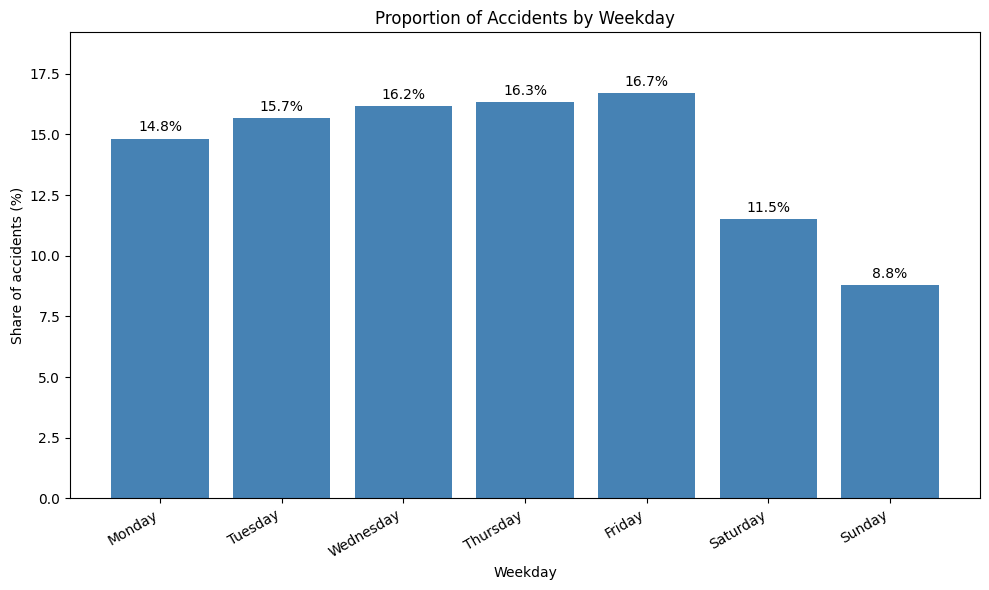

In [5]:
# Accidents by weekday
import matplotlib.pyplot as plt

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_counts = df["dia_semana"].value_counts().reindex(weekday_order, fill_value=0)

weekday_proportions = weekday_counts / weekday_counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(weekday_proportions.index, weekday_proportions.values, color="steelblue")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_title("Proportion of Accidents by Weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Share of accidents (%)")
ax.set_ylim(0, weekday_proportions.max() * 1.15)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

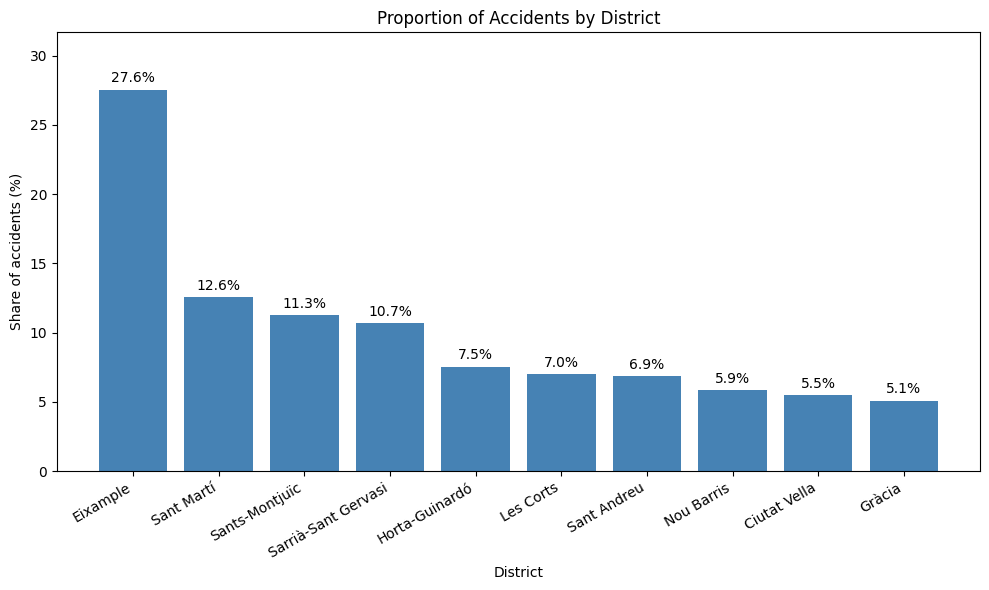

In [ ]:
# Accidents by district
## THOUGHT : maybe also consider size of the districts? 

#weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
district_counts = df["nom_districte"].value_counts()

district_proportions = district_counts / district_counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(district_proportions.index, district_proportions.values, color="steelblue")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_title("Proportion of Accidents by District")
ax.set_xlabel("District")
ax.set_ylabel("Share of accidents (%)")
ax.set_ylim(0, district_proportions.max() * 1.15)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Proportion of Accidents Caused by Pedestrians')

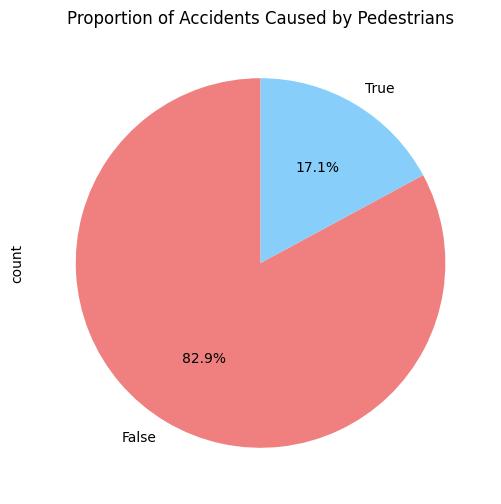

In [11]:
# Pie chart of accidents depending on cause by pedestrian 

causa_vianant_counts = df["es_causa_vianant"].value_counts()
causa_vianant_proportions = causa_vianant_counts / causa_vianant_counts.sum() * 100

causa_vianant_proportions.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(6, 6), colors=['lightcoral', 'lightskyblue'])
plt.title("Proportion of Accidents Caused by Pedestrians")   

Text(0.5, 1.0, 'Number of Accidents by Hour of the Day')

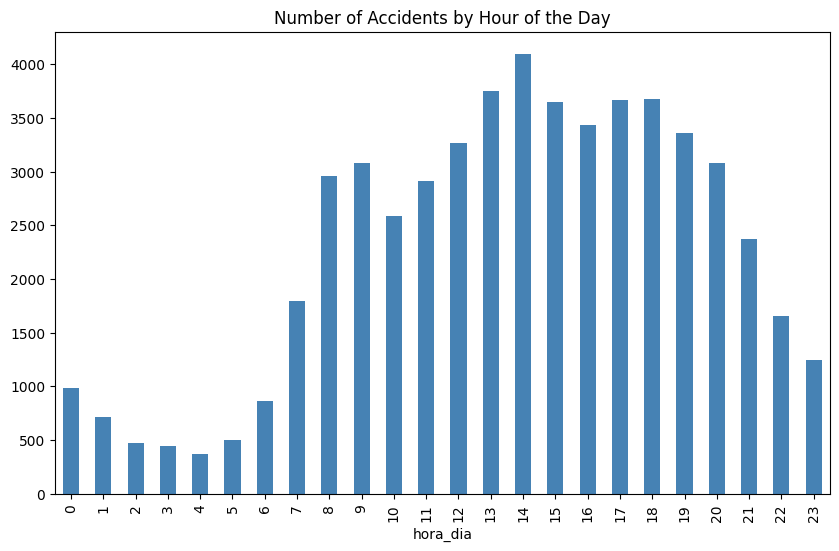

In [12]:
# histogram of accidents by hour of the day 

hora_counts = df["hora_dia"].value_counts().sort_index()
ax = hora_counts.plot(kind='bar', figsize=(10, 6), color='steelblue')
ax.set_title("Number of Accidents by Hour of the Day")

43794 accidents on laborable days
11160 accidents on weekend days


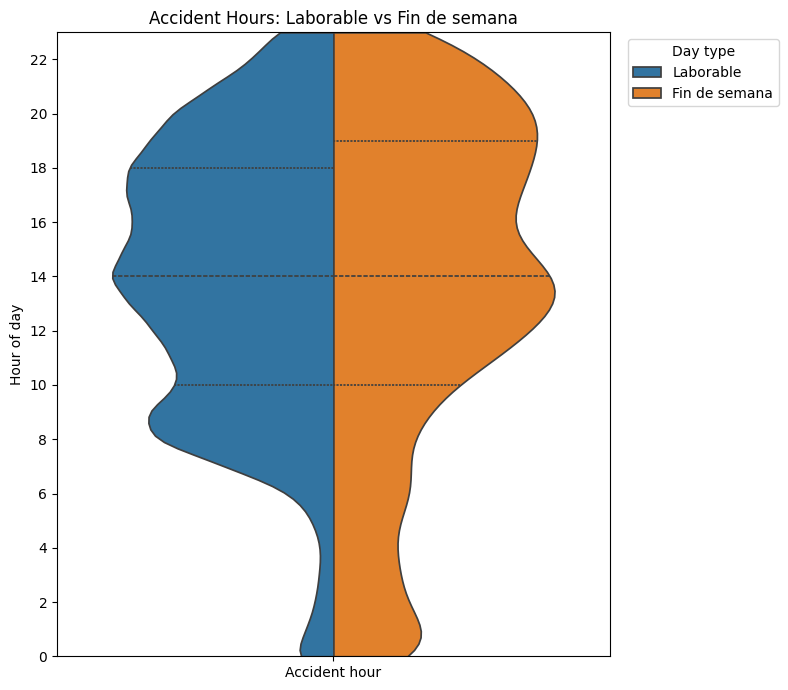

In [5]:
# Split violin of accident hours: laborable on the left, weekend on the right
import seaborn as sns

### COMMENT : plot seems like there are more weekend accidents
##          even though the opposite is true, what is shown is 
##         the distribution of accidents by hour, not the total number of accidents
plot_data = df.loc[
    df["fin_de_semana"].isin(["Laborable", "Fin de semana"]),
    ["hora_dia", "fin_de_semana"],
].copy()
plot_data["comparison"] = "Accident hour"

fig, ax = plt.subplots(figsize=(8, 7))
sns.violinplot(
    data=plot_data,
    x="comparison",
    y="hora_dia",
    hue="fin_de_semana",
    hue_order=["Laborable", "Fin de semana"],
    split=True,
    inner="quart",
    cut=0,
    density_norm="area",
    ax=ax,
)
ax.set_title("Accident Hours: Laborable vs Fin de semana")
ax.set_xlabel("")
ax.set_ylabel("Hour of day")
ax.set_ylim(0, 23)
ax.set_yticks(range(0, 24, 2))
ax.legend(title="Day type", loc="upper left", bbox_to_anchor=(1.02, 1))
fig.tight_layout()


num_acc_lab = sum(df["fin_de_semana"] == "Laborable")
num_acc_fds = sum(df["fin_de_semana"] == "Fin de semana")
print(num_acc_lab, "accidents on laborable days")
print(num_acc_fds, "accidents on weekend days")

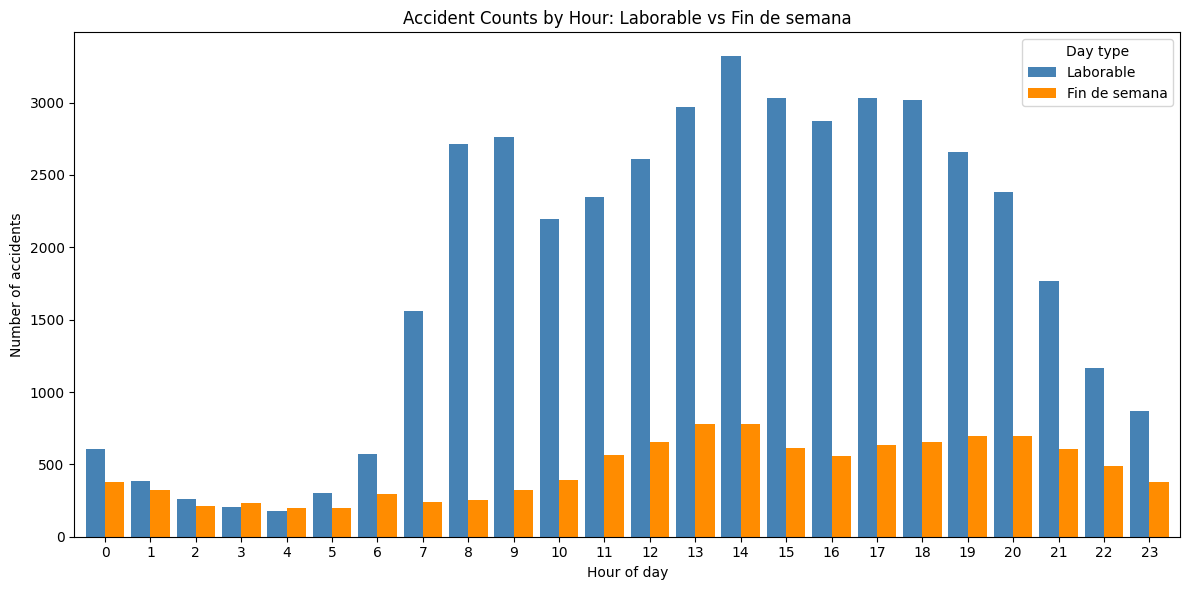

In [6]:
### COMMENT: This better shows the actual total number of accidents,
##          and how it is lower on the weekends, but it is less visible
##          that e.g. on the weekedns there are more accidents at night


counts_by_hour = pd.crosstab(
    df["hora_dia"],
    df["fin_de_semana"]
).reindex(
    index=range(24),
    columns=["Laborable", "Fin de semana"],
    fill_value=0
)

ax = counts_by_hour.plot(
    kind="bar",
    figsize=(12, 6),
    color=["steelblue", "darkorange"],
    width=0.85
)

ax.set_title("Accident Counts by Hour: Laborable vs Fin de semana")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of accidents")
ax.legend(title="Day type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()